# Fractal Alphabet Demo / Демонстрация фрактального алфавита

**RU.** Этот notebook объясняет фрактальный алфавит как ключевой элемент фрактального числа. Мы не разбираем здесь полный транспортный пакет, residual peeling, хранение ID и хранение таблиц состояний. Цель уже: визуально показать, как алфавит задает параметры генераторов, почему его матрица диагональна, как растет основание старших разрядов и как значение разряда выбирает ячейку `(P, S)`.

Фрактальные числа предназначены для эффективной работы с большими числовыми payload в импульсном режиме: в памяти, в импульсных нейронных сетях и в специализированных вычислителях. В этом notebook мы смотрим на самый базовый слой: фрактальный алфавит как пространство допустимых параметров генераторов.

**EN.** This notebook explains the fractal alphabet as the core component of a fractal number. It does not cover the full transport packet, residual peeling, ID storage, or state-table storage. The goal is narrower: to visualize how the alphabet defines generator parameters, why the alphabet matrix is diagonal, how higher digit radices grow, and how a digit value selects a `(P, S)` cell.

Fractal numbers are designed for efficient storage and transmission of large numeric payloads in pulse-based systems: memory, spiking neural networks, and specialized computing hardware. In this notebook we focus on the most basic layer: the fractal alphabet as the space of legal generator parameters.

## Notebook Roadmap / План notebook

1. Motivation and generator formula / мотивация и формула генератора.
2. Single-channel fractal alphabet / фрактальный алфавит одного разряда.
3. Diagonal structure and valid cells / диагональность и допустимые ячейки.
4. Variable alphabet height / варьируемая высота алфавита.
5. Multi-digit dynamic alphabet / динамический алфавит нескольких разрядов.
6. Decimal number encoding into selected cells / кодирование числа в выбранные ячейки.
7. Conclusions / выводы.

In [1]:
from pathlib import Path
import math
import sys

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "experiments" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from snn_framework import ChannelAlphabet, MatrixFractalNumber

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_rows", 80)


def bits_for_levels(levels: int) -> int:
    return max(1, math.ceil(math.log2(levels)))


def capacity_bits(model: MatrixFractalNumber, digit_count: int) -> float:
    return sum(math.log2(model.radix(i)) for i in range(digit_count))


def minimal_digit_count_for_bits(model: MatrixFractalNumber, payload_bits: int) -> int:
    total = 0.0
    digit_count = 0
    while total < payload_bits:
        total += math.log2(model.radix(digit_count))
        digit_count += 1
    return digit_count


def alphabet_dataframe(alphabet: ChannelAlphabet) -> pd.DataFrame:
    rows = []
    digit_value = 0
    for row_index, period in enumerate(alphabet.periods):
        for shift in range(period):
            rows.append({
                "row index": row_index,
                "period P": period,
                "shift S": shift,
                "digit value V": digit_value,
                "generator cell": f"P={period}, S={shift}",
            })
            digit_value += 1
    return pd.DataFrame(rows)


def alphabet_matrix(alphabet: ChannelAlphabet) -> pd.DataFrame:
    max_shift = alphabet.max_period - 1
    rows = []
    for period in alphabet.periods:
        row = {"P": period}
        for shift in range(max_shift + 1):
            row[f"S={shift}"] = "" if shift >= period else sum(p for p in alphabet.periods if p < period) + shift
        rows.append(row)
    return pd.DataFrame(rows).set_index("P")


def plot_alphabet(alphabet: ChannelAlphabet, title: str, selected: tuple[int, int] | None = None):
    max_shift = alphabet.max_period - 1
    data = []
    labels = []
    for period in alphabet.periods:
        row = []
        label_row = []
        prefix = sum(p for p in alphabet.periods if p < period)
        for shift in range(max_shift + 1):
            if shift < period:
                row.append(prefix + shift + 1)
                label_row.append(str(prefix + shift))
            else:
                row.append(float("nan"))
                label_row.append("")
        data.append(row)
        labels.append(label_row)

    fig, ax = plt.subplots(figsize=(min(14, 4 + max_shift * 0.55), 0.7 * len(alphabet.periods) + 2.5))
    ax.imshow(data, cmap="viridis", aspect="auto")

    for y, period in enumerate(alphabet.periods):
        for shift in range(max_shift + 1):
            if labels[y][shift]:
                color = "white" if data[y][shift] > alphabet.radix * 0.45 else "black"
                ax.text(shift, y, labels[y][shift], ha="center", va="center", fontsize=9, color=color)

    if selected is not None:
        selected_period, selected_shift = selected
        y = list(alphabet.periods).index(selected_period)
        ax.scatter([selected_shift], [y], s=420, facecolors="none", edgecolors="red", linewidths=3)
        ax.text(selected_shift, y - 0.35, "selected", ha="center", va="bottom", color="red", fontsize=10, weight="bold")

    ax.set_xticks(range(max_shift + 1), labels=[f"S={i}" for i in range(max_shift + 1)])
    ax.set_yticks(range(len(alphabet.periods)), labels=[f"P={p}" for p in alphabet.periods])
    ax.set_xlabel("Start delay / Сдвиг старта S")
    ax.set_ylabel("Period row / Строка периода P")
    ax.set_title(title)
    ax.grid(False)
    fig.tight_layout()
    return fig, ax


def model_summary(model: MatrixFractalNumber, digit_count: int) -> pd.DataFrame:
    rows = []
    running_capacity = 0.0
    for digit_index in range(digit_count):
        alphabet = model.channel_alphabet(digit_index)
        running_capacity += math.log2(alphabet.radix)
        rows.append({
            "digit i": digit_index,
            "role": "least significant / младший" if digit_index == 0 else "more significant / старший",
            "period band": f"{alphabet.periods[0]}..{alphabet.periods[-1]}",
            "height rows": len(alphabet.periods),
            "dynamic width max S": alphabet.max_period - 1,
            "Base_i = sum(P)": alphabet.radix,
            "log2(Base_i), bits": round(math.log2(alphabet.radix), 3),
            "cumulative capacity, bits": round(running_capacity, 3),
        })
    return pd.DataFrame(rows)


def encode_value_table(model: MatrixFractalNumber, value: int, digit_count: int) -> pd.DataFrame:
    digits = model.encode_digits(value, digit_count=digit_count)
    cells = model.encode_cells(value, digit_count=digit_count)
    rows = []
    for cell in cells:
        alphabet = model.channel_alphabet(cell.digit_index)
        rows.append({
            "digit i": cell.digit_index,
            "Base_i": alphabet.radix,
            "digit V_i": cell.digit_value,
            "period band": f"{alphabet.periods[0]}..{alphabet.periods[-1]}",
            "selected period P_i": cell.period_ticks,
            "selected shift S_i": cell.shift_ticks,
            "period index": cell.period_index,
            "cell formula": f"V_i = sum(previous P rows) + S = {cell.digit_value}",
        })
    assert model.decode_digits(digits) == value
    return pd.DataFrame(rows)


def binary_parameters_table(cells, limit: int = 24) -> pd.DataFrame:
    rows = []
    for cell in cells[:limit]:
        rows.append({
            "digit i": cell.digit_index,
            "P_i decimal": cell.period_ticks,
            "S_i decimal": cell.shift_ticks,
            "P_i binary": bin(cell.period_ticks),
            "S_i binary": bin(cell.shift_ticks),
            "P bits": bits_for_levels(cell.period_ticks + 1),
            "S bits": bits_for_levels(cell.period_ticks),
        })
    return pd.DataFrame(rows)

## 1. Why A Fractal Alphabet Exists / Зачем нужен фрактальный алфавит

**RU.** Фрактальное число хранит значение не как плоскую последовательность битов во времени, а как набор параметров генераторов. Каждый разряд выбирает одну ячейку алфавита. Эта ячейка задает два физических параметра канального генератора:

- период `P_i`, то есть временной масштаб генератора;
- сдвиг старта `S_i`, то есть сколько тактов канал молчит перед первым циклом.

После выбора ячейки канал может быть развернут во времени как бинарный step-generator:

$$
C_i(t; P_i, S_i) =
\begin{cases}
0, & t < S_i \\
\mathbb{1}\left[((t - S_i) \bmod P_i) \ge \left\lfloor P_i / 2 \right\rfloor\right], & t \ge S_i
\end{cases}
$$

Суммарный импульсный payload может передаваться как многоуровневый сигнал:

$$
A(t) = \sum_{i=0}^{m-1} \alpha_i C_i(t; P_i, S_i)
$$

В этом notebook нас интересует не сам сигнал `A(t)`, а алфавит, который выбирает параметры `P_i` и `S_i`.

**EN.** A fractal number stores a value not as a flat temporal bit sequence, but as a set of generator parameters. Each digit selects one alphabet cell. That cell defines two physical parameters of the channel generator:

- period `P_i`, the temporal scale of the generator;
- start delay `S_i`, the number of ticks for which the channel stays silent before its first cycle.

After a cell is selected, the channel can be unfolded into time as a binary step-generator. The full payload can then be transmitted as the summed amplitude stream `A(t)`. In this notebook we focus on the alphabet that selects `P_i` and `S_i`, not on the full signal-decoding pipeline.

## 2. A Simple Single-Digit Alphabet / Простой алфавит одного разряда

**RU.** Начнем с одного разряда. Пусть доступны периоды `P = {2, 3, 4, 5}`. Это высота алфавита: четыре строки периода. Важное правило диагонального алфавита: строка с периодом `P` содержит ровно `P` допустимых сдвигов `S = 0..P-1`.

Периоды идут по высоте с шагом `1`. Горизонтальная ширина не фиксируется вручную: она автоматически определяется периодом строки. Если строка имеет `P=2`, в ней 2 ячейки. Если строка имеет `P=5`, в ней 5 ячеек. Поэтому основание разряда равно сумме длин строк:

$$
Base_i = \sum_{P \in periods_i} P
$$

**EN.** Start with a single digit. Let the available periods be `P = {2, 3, 4, 5}`. This is the alphabet height: four period rows. The core rule of the diagonal alphabet is that a row with period `P` has exactly `P` legal shifts `S = 0..P-1`.

The period step along the vertical axis is `1`. The horizontal width is not manually fixed: it is automatically determined by the row period. A `P=2` row has 2 cells; a `P=5` row has 5 cells. Therefore the digit radix is the sum of row lengths.

,period rows,height rows,max horizontal shift,Base = sum(P),capacity bits log2(Base)
0,"(2, 3, 4, 5)",4,4,14,3.807


,row index,period P,shift S,digit value V,generator cell
0,0,2,0,0,"P=2, S=0"
1,0,2,1,1,"P=2, S=1"
2,1,3,0,2,"P=3, S=0"
3,1,3,1,3,"P=3, S=1"
4,1,3,2,4,"P=3, S=2"
5,2,4,0,5,"P=4, S=0"
6,2,4,1,6,"P=4, S=1"
7,2,4,2,7,"P=4, S=2"
8,2,4,3,8,"P=4, S=3"
9,3,5,0,9,"P=5, S=0"


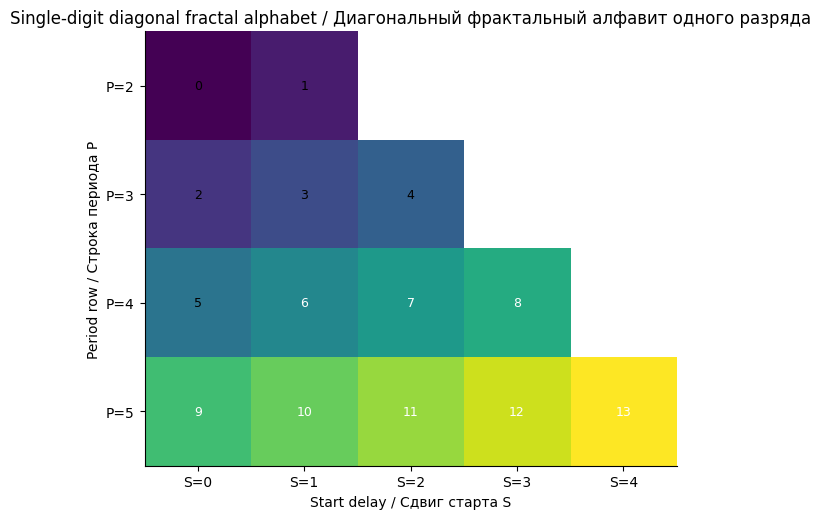

In [2]:
simple_alphabet = ChannelAlphabet(range(2, 6))

summary = pd.DataFrame([
    {
        "period rows": simple_alphabet.periods,
        "height rows": len(simple_alphabet.periods),
        "max horizontal shift": simple_alphabet.max_period - 1,
        "Base = sum(P)": simple_alphabet.radix,
        "capacity bits log2(Base)": round(math.log2(simple_alphabet.radix), 3),
    }
])

display(summary)
display(alphabet_dataframe(simple_alphabet))
plot_alphabet(simple_alphabet, "Single-digit diagonal fractal alphabet / Диагональный фрактальный алфавит одного разряда");

### Table Field Definitions / Определения полей таблиц

**RU. Первая таблица:**

- `period rows`: набор допустимых периодов в алфавите разряда.
- `height rows`: высота алфавита, то есть число строк периода.
- `max horizontal shift`: максимальный индекс сдвига, который может встретиться в таблице.
- `Base = sum(P)`: основание разряда, равное количеству допустимых ячеек.
- `capacity bits log2(Base)`: емкость разряда в битах.

**EN. First table:**

- `period rows`: allowed periods in the digit alphabet.
- `height rows`: alphabet height, or the number of period rows.
- `max horizontal shift`: maximum shift index that may appear in the table.
- `Base = sum(P)`: digit radix, equal to the number of legal cells.
- `capacity bits log2(Base)`: digit capacity in bits.

**RU. Вторая таблица:**

- `row index`: индекс строки периода внутри алфавита.
- `period P`: физический период генератора.
- `shift S`: сдвиг старта генератора.
- `digit value V`: значение разряда, соответствующее ячейке `(P, S)`.
- `generator cell`: текстовое представление выбранной пары параметров.

**EN. Second table:**

- `row index`: period-row index inside the alphabet.
- `period P`: physical generator period.
- `shift S`: generator start delay.
- `digit value V`: digit value represented by cell `(P, S)`.
- `generator cell`: text representation of the selected parameter pair.

## 3. What Diagonal Means / Что означает диагональность

**RU.** Если нарисовать алфавит как таблицу `(P, S)`, то не все прямоугольное поле является допустимым. Для строки периода `P` допустимы только сдвиги `0 <= S < P`. Все ячейки справа от границы `S = P - 1` запрещены.

Именно поэтому форма алфавита диагональная: граница допустимых ячеек идет по диагонали таблицы. Это не декоративная форма, а инженерное ограничение. Оно упрощает декодирование в импульсной передаче:

- сдвиг старта никогда не превышает длину периода;
- каждая строка имеет естественное число фазовых положений;
- значение разряда восстанавливается через кумулятивную сумму предыдущих строк и локальный сдвиг;
- декодер получает ограниченный набор допустимых period-shift кандидатов, а не произвольную прямоугольную сетку.

**EN.** If the alphabet is drawn as a `(P, S)` table, the full rectangle is not valid. For a period row `P`, legal shifts satisfy `0 <= S < P`. Cells to the right of the boundary `S = P - 1` are invalid.

This is why the alphabet is diagonal: the valid-cell boundary forms a diagonal line across the table. The shape is not decorative; it is an engineering constraint that simplifies decoding in pulse-based transmission. The start delay never exceeds the period, each row has a natural number of phase positions, and the decoder searches a constrained set of legal period-shift candidates.

,S=0,S=1,S=2,S=3,S=4
P,,,,,
2,0,1,,,
3,2,3,4,,
4,5,6,7,8,
5,9,10,11,12,13


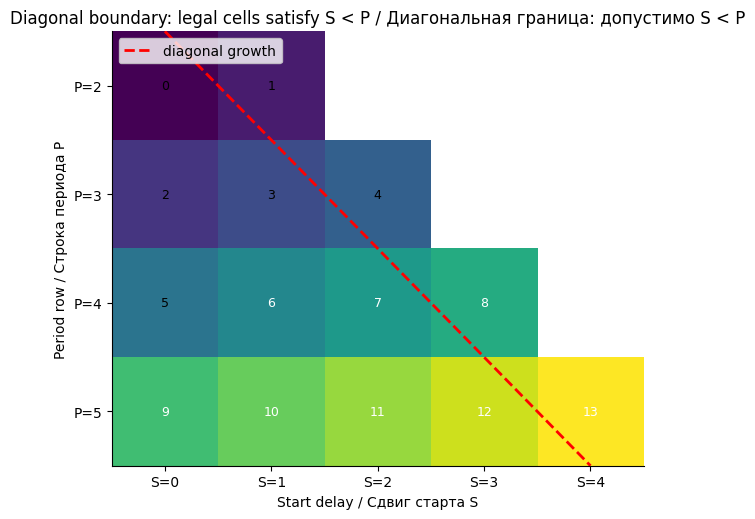

In [3]:
matrix_view = alphabet_matrix(simple_alphabet)
display(matrix_view)

fig, ax = plot_alphabet(simple_alphabet, "Diagonal boundary: legal cells satisfy S < P / Диагональная граница: допустимо S < P")
ax.plot([0, simple_alphabet.max_period - 1], [-0.5, len(simple_alphabet.periods) - 0.5], color="red", linewidth=2, linestyle="--", label="diagonal growth")
ax.legend(loc="upper left");

### Table Field Definitions / Определения полей таблицы

**RU.**

В этой матрице строки соответствуют периодам `P`, а столбцы соответствуют сдвигам `S`.

- `P`: период строки алфавита.
- `S=0`, `S=1`, ...: возможные сдвиги старта генератора.
- число в ячейке: значение разряда `V_i`, которое выбирает эту ячейку.
- пустая ячейка: запрещенная комбинация, потому что для строки `P` допустимы только `S < P`.

**EN.**

In this matrix, rows are periods `P`, and columns are shifts `S`.

- `P`: alphabet period row.
- `S=0`, `S=1`, ...: possible generator start delays.
- cell number: digit value `V_i` that selects this cell.
- empty cell: invalid combination, because row `P` only allows `S < P`.

## 4. Height Is A Parameter / Высота алфавита как параметр

**RU.** Высота алфавита — это количество строк периода в одном разряде. Ее можно выбирать под задачу и аппаратные ограничения. Небольшая высота дает короткий и простой алфавит. Большая высота увеличивает основание разряда и позволяет хранить больше состояний в одном разряде, но также расширяет диапазон возможных периодов.

Ниже показано, как меняется емкость одного разряда при разной высоте алфавита. Периоды всегда идут непрерывно с шагом `1`, а ширина каждой строки по-прежнему равна самому периоду.

**EN.** Alphabet height is the number of period rows in one digit. It can be chosen according to the task and hardware constraints. A smaller height gives a shorter and simpler alphabet. A larger height increases the digit radix and stores more states per digit, but it also expands the range of possible periods.

The next table shows how the capacity of one digit changes with different alphabet heights. Periods remain contiguous with step `1`, and each row width is still equal to the period itself.

,alphabet height,period band,Base = sum(P),capacity bits,max row width
0,2,2..3,5,2.322,3
1,4,2..5,14,3.807,5
2,8,2..9,44,5.459,9
3,16,2..17,152,7.248,17


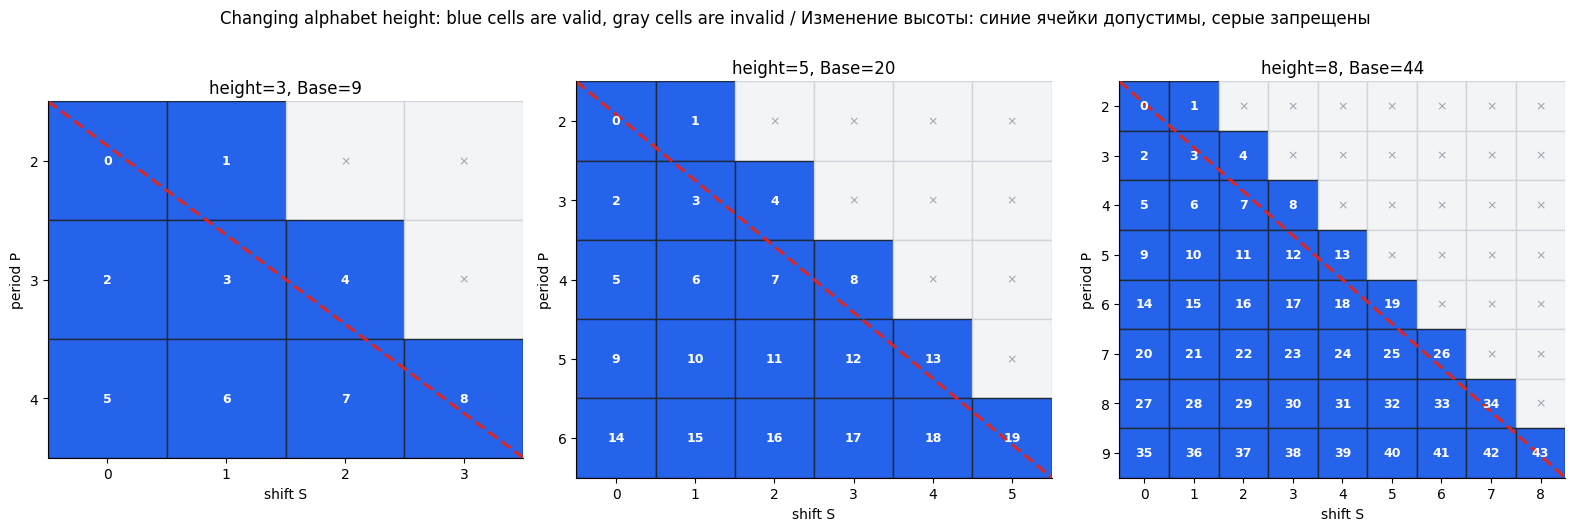

In [4]:
height_rows = []
for height in [2, 4, 8, 16]:
    alphabet = ChannelAlphabet(range(2, 2 + height))
    height_rows.append({
        "alphabet height": height,
        "period band": f"{alphabet.periods[0]}..{alphabet.periods[-1]}",
        "Base = sum(P)": alphabet.radix,
        "capacity bits": round(math.log2(alphabet.radix), 3),
        "max row width": alphabet.max_period,
    })
height_df = pd.DataFrame(height_rows)
display(height_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, height in zip(axes, [3, 5, 8]):
    alphabet = ChannelAlphabet(range(2, 2 + height))
    max_shift = alphabet.max_period - 1
    valid_cells = 0

    for y, period in enumerate(alphabet.periods):
        for shift in range(max_shift + 1):
            is_valid = shift < period
            facecolor = "#2563EB" if is_valid else "#F3F4F6"
            edgecolor = "#1F2937" if is_valid else "#D1D5DB"
            rect = plt.Rectangle((shift - 0.5, y - 0.5), 1, 1, facecolor=facecolor, edgecolor=edgecolor, linewidth=1.0)
            ax.add_patch(rect)
            if is_valid:
                ax.text(shift, y, str(valid_cells), ha="center", va="center", color="white", fontsize=9, weight="bold")
                valid_cells += 1
            else:
                ax.text(shift, y, "×", ha="center", va="center", color="#9CA3AF", fontsize=9)

    ax.plot([-0.5, max_shift + 0.5], [-0.5, len(alphabet.periods) - 0.5], color="#DC2626", linewidth=2.2, linestyle="--")
    ax.set_xlim(-0.5, max_shift + 0.5)
    ax.set_ylim(len(alphabet.periods) - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.set_title(f"height={height}, Base={alphabet.radix}")
    ax.set_xlabel("shift S")
    ax.set_ylabel("period P")
    ax.set_xticks(range(max_shift + 1))
    ax.set_yticks(range(len(alphabet.periods)), labels=[str(p) for p in alphabet.periods])
    ax.grid(False)
fig.suptitle("Changing alphabet height: blue cells are valid, gray cells are invalid / Изменение высоты: синие ячейки допустимы, серые запрещены", y=1.05)
fig.tight_layout();

### Table Field Definitions / Определения полей таблицы

**RU.**

- `alphabet height`: количество строк периода в алфавите.
- `period band`: минимальный и максимальный период в данном алфавите.
- `Base = sum(P)`: основание разряда, равное сумме всех допустимых периодов.
- `capacity bits`: информационная емкость одного разряда, `log2(Base)`.
- `max row width`: максимальная ширина строки, равная максимальному периоду.

**EN.**

- `alphabet height`: number of period rows in the alphabet.
- `period band`: minimum and maximum period in this alphabet.
- `Base = sum(P)`: digit radix, equal to the sum of all legal periods.
- `capacity bits`: information capacity of one digit, `log2(Base)`.
- `max row width`: maximum row width, equal to the maximum period.

## 5. Digits And Dynamic Growth / Разряды и динамический рост

**RU.** Как и обычные числа, фрактальные числа имеют разряды. Разряд `0` является младшим и использует самый быстрый диапазон периодов. Каждый следующий старший разряд получает следующий непересекающийся диапазон периодов.

Если высота алфавита равна `4`, то разряды могут выглядеть так:

- digit `0`: periods `2..5`, Base `14`;
- digit `1`: periods `6..9`, Base `30`;
- digit `2`: periods `10..13`, Base `46`;
- digit `3`: periods `14..17`, Base `62`.

Основание старших разрядов растет автоматически, потому что их периоды больше, а каждая строка периода `P` имеет `P` допустимых сдвигов. Это дает mixed-radix систему, где старшие разряды обладают большей емкостью.

**EN.** Like ordinary numbers, fractal numbers have digits. Digit `0` is the least significant digit and uses the fastest period band. Each next higher digit receives the next non-overlapping period band.

With alphabet height `4`, digit `0` may use periods `2..5`, digit `1` periods `6..9`, digit `2` periods `10..13`, and so on. Higher digit radices grow automatically because their periods are larger, and each period row `P` has `P` legal shifts. This creates a mixed-radix system where more significant digits have larger capacity.

,digit i,role,period band,height rows,dynamic width max S,Base_i = sum(P),"log2(Base_i), bits","cumulative capacity, bits"
0,0,least significant / младший,2..5,4,4,14,3.807,3.807
1,1,more significant / старший,6..9,4,8,30,4.907,8.714
2,2,more significant / старший,10..13,4,12,46,5.524,14.238
3,3,more significant / старший,14..17,4,16,62,5.954,20.192
4,4,more significant / старший,18..21,4,20,78,6.285,26.477
5,5,more significant / старший,22..25,4,24,94,6.555,33.032
6,6,more significant / старший,26..29,4,28,110,6.781,39.813
7,7,more significant / старший,30..33,4,32,126,6.977,46.791


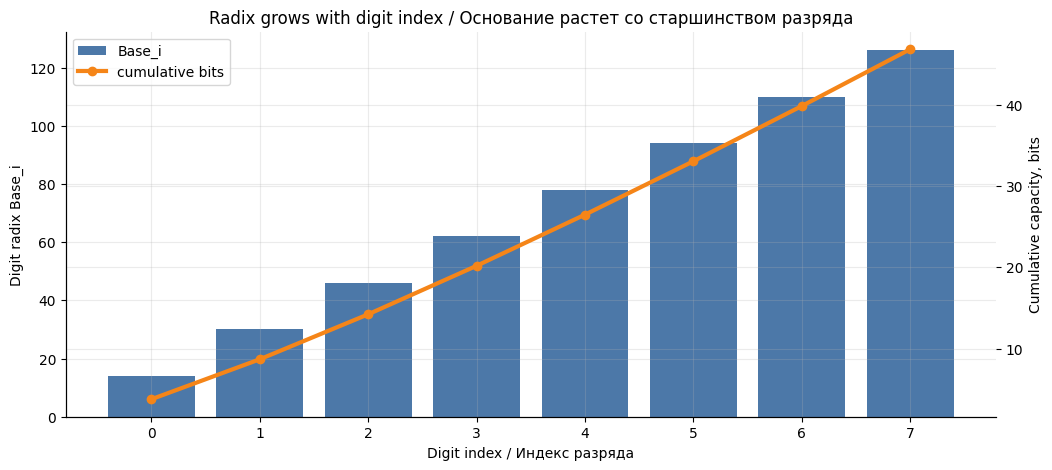

In [5]:
alphabet_height = 4
model = MatrixFractalNumber.from_contiguous_bands(start=2, width=alphabet_height)
digit_count = 8
summary_df = model_summary(model, digit_count)
display(summary_df)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(summary_df["digit i"], summary_df["Base_i = sum(P)"], color="#4C78A8", label="Base_i")
ax1.set_xlabel("Digit index / Индекс разряда")
ax1.set_ylabel("Digit radix Base_i")
ax1.set_title("Radix grows with digit index / Основание растет со старшинством разряда")

ax2 = ax1.twinx()
ax2.plot(summary_df["digit i"], summary_df["cumulative capacity, bits"], color="#F58518", marker="o", linewidth=3, label="cumulative bits")
ax2.set_ylabel("Cumulative capacity, bits")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left");

### Table Field Definitions / Определения полей таблицы

**RU.**

- `digit i`: индекс разряда фрактального числа.
- `role`: роль разряда: младший или более старший.
- `period band`: диапазон периодов, выделенный этому разряду.
- `height rows`: высота алфавита, то есть количество строк периода.
- `dynamic width max S`: максимальный допустимый сдвиг в этом разряде.
- `Base_i = sum(P)`: основание разряда, равное сумме длин строк.
- `log2(Base_i), bits`: информационная емкость одного разряда в битах.
- `cumulative capacity, bits`: накопленная емкость всех разрядов от `0` до текущего.

**EN.**

- `digit i`: fractal digit index.
- `role`: digit role: least significant or more significant.
- `period band`: period range assigned to this digit.
- `height rows`: alphabet height, or the number of period rows.
- `dynamic width max S`: maximum legal shift in this digit.
- `Base_i = sum(P)`: digit radix, equal to the sum of row lengths.
- `log2(Base_i), bits`: information capacity of one digit in bits.
- `cumulative capacity, bits`: accumulated capacity from digit `0` through the current digit.

## 6. Encoding A Decimal Number Into Alphabet Cells / Кодирование десятичного числа в ячейки алфавита

**RU.** Теперь покажем, как число хранится во фрактальном виде. Пусть нужно закодировать десятичное число `348`. Сначала число раскладывается в mixed-radix разряды. Затем значение каждого разряда `V_i` выбирает одну ячейку в алфавите своего канала.

Выбор ячейки идет простым правилом:

$$
V_i = \sum_{P \in rows\ before\ selected\ row} P + S_i
$$

То есть мы последовательно проходим строки периода. Как только остаток меньше длины текущей строки `P`, эта строка становится выбранным периодом, а остаток становится сдвигом `S_i`.

**EN.** Now we show how a number is stored in fractal form. Let the decimal value be `348`. First, the value is decomposed into mixed-radix digits. Then each digit value `V_i` selects one cell in its channel alphabet.

Cell selection is simple: walk through period rows cumulatively. When the remaining digit value is smaller than the current row length `P`, that row becomes the selected period and the remainder becomes the shift `S_i`.

**Decimal value / Десятичное значение:** `348`

,digit i,Base_i,digit V_i,period band,selected period P_i,selected shift S_i,period index,cell formula
0,0,14,12,2..5,5,3,3,V_i = sum(previous P rows) + S = 12
1,1,30,24,6..9,9,3,3,V_i = sum(previous P rows) + S = 24


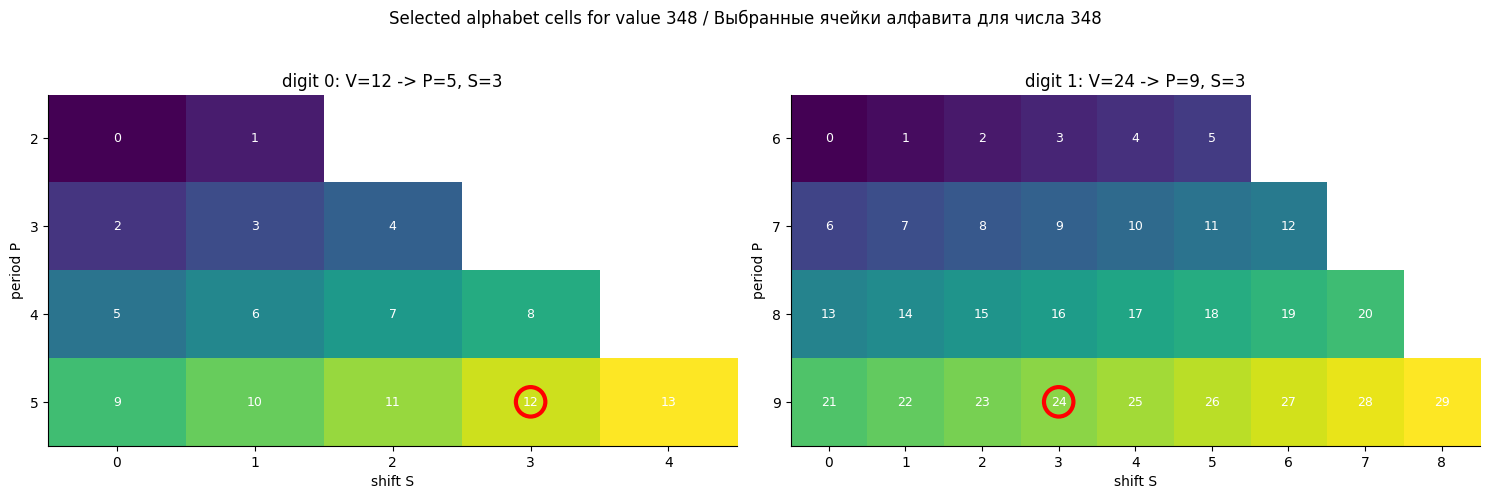

In [6]:
value = 348
digit_count = 2
encoded_df = encode_value_table(model, value, digit_count)
display(Markdown(f"**Decimal value / Десятичное значение:** `{value}`"))
display(encoded_df)

cells = model.encode_cells(value, digit_count=digit_count)
fig, axes = plt.subplots(1, digit_count, figsize=(15, 4.8))
for ax, cell in zip(axes, cells):
    alphabet = model.channel_alphabet(cell.digit_index)
    max_shift = alphabet.max_period - 1
    data = []
    labels = []
    for period in alphabet.periods:
        row = []
        label_row = []
        prefix = sum(p for p in alphabet.periods if p < period)
        for shift in range(max_shift + 1):
            if shift < period:
                row.append(prefix + shift + 1)
                label_row.append(str(prefix + shift))
            else:
                row.append(float("nan"))
                label_row.append("")
        data.append(row)
        labels.append(label_row)
    ax.imshow(data, cmap="viridis", aspect="auto")
    for y, period in enumerate(alphabet.periods):
        for shift in range(max_shift + 1):
            if label_row is not None and labels[y][shift]:
                ax.text(shift, y, labels[y][shift], ha="center", va="center", fontsize=9, color="white")
    selected_y = list(alphabet.periods).index(cell.period_ticks)
    ax.scatter([cell.shift_ticks], [selected_y], s=450, facecolors="none", edgecolors="red", linewidths=3)
    ax.set_title(f"digit {cell.digit_index}: V={cell.digit_value} -> P={cell.period_ticks}, S={cell.shift_ticks}")
    ax.set_xticks(range(max_shift + 1), labels=[str(s) for s in range(max_shift + 1)])
    ax.set_yticks(range(len(alphabet.periods)), labels=[str(p) for p in alphabet.periods])
    ax.set_xlabel("shift S")
    ax.set_ylabel("period P")
    ax.grid(False)
fig.suptitle("Selected alphabet cells for value 348 / Выбранные ячейки алфавита для числа 348", y=1.03)
fig.tight_layout();

### Table Field Definitions / Определения полей таблицы

**RU.**

- `digit i`: индекс фрактального разряда; `0` — младший разряд.
- `Base_i`: основание разряда, равное сумме периодов его алфавита.
- `digit V_i`: значение mixed-radix разряда.
- `period band`: диапазон периодов, доступный этому разряду.
- `selected period P_i`: выбранный период генератора.
- `selected shift S_i`: выбранный сдвиг старта генератора.
- `period index`: индекс строки выбранного периода внутри алфавита.
- `cell formula`: формула восстановления значения разряда из выбранной строки и сдвига.

**EN.**

- `digit i`: fractal digit index; `0` is the least significant digit.
- `Base_i`: digit radix, equal to the sum of periods in its alphabet.
- `digit V_i`: mixed-radix digit value.
- `period band`: period range available to this digit.
- `selected period P_i`: selected generator period.
- `selected shift S_i`: selected generator start delay.
- `period index`: row index of the selected period inside the alphabet.
- `cell formula`: formula that reconstructs the digit value from the selected row and shift.

## 7. Conclusions / Выводы

**RU.** Фрактальный алфавит задает структурированное пространство параметров генераторов. Его ключевые свойства:

- периодические строки идут с шагом `1`, что делает алфавит регулярным и простым для аппаратной реализации;
- строка периода `P` содержит ровно `P` допустимых сдвигов, поэтому ширина растет автоматически;
- допустимые ячейки образуют диагональную матрицу, ограничивая пространство возможных period-shift параметров;
- каждый следующий старший разряд получает больший period band и большее основание `Base_i`;
- высота алфавита является варьируемым параметром, который управляет емкостью одного разряда;
- значение разряда `V_i` детерминированно выбирает ячейку `(P_i, S_i)`.

Главный практический вывод: фрактальный алфавит является мостом между числом и генератором. Он показывает, какие параметры может принять каждый разряд, как эти параметры организованы визуально и почему диагональная структура удобна для импульсного декодирования.

**EN.** The fractal alphabet defines a structured parameter space for generators. Its core properties are:

- period rows are contiguous with step `1`, which makes the alphabet regular and hardware-friendly;
- a period row `P` contains exactly `P` legal shifts, so row width grows automatically;
- legal cells form a diagonal matrix, constraining the space of possible period-shift parameters;
- each next higher digit receives a larger period band and a larger radix `Base_i`;
- alphabet height is a tunable parameter controlling one-digit capacity;
- digit value `V_i` deterministically selects a cell `(P_i, S_i)`.

The main practical result is that the fractal alphabet is the bridge between a number and a generator. It shows which parameters each digit may take, how these parameters are organized visually, and why the diagonal structure is convenient for pulse-based decoding.